# 🎓 Multi-Agent Systems
**Disciplina:** GENERATIVE AI & ADAVANCED NETS  
**Curso:** Tecnólogo em Inteligência Artificial

## 📌 Objetivos de Aprendizagem
Ao final desta sessão prática, você será capaz de:
- explicar a diferença entre um agente isolado e um sistema multiagente;
- construir agentes especializados com responsabilidades diferentes;
- compartilhar estado entre agentes usando LangGraph;
- criar um workflow com routing condicional e loop agentivo;
- representar regras antifraude como estruturas de dados, sem executar código gerado pelo LLM;
- validar uma regra proposta por agentes usando métricas objetivas em dados reais de fraude.

# 1. Introdução — por que um agente só não é suficiente?

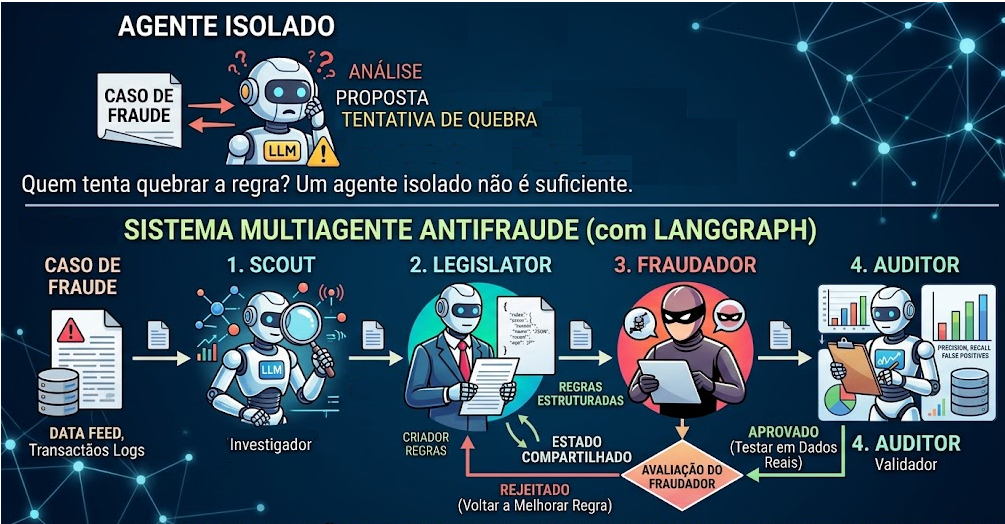

A ideia central é:

```text
Fraud Case
    ↓
 SCOUT
    ↓
LEGISLATOR
    ↓
FRAUDADOR
    ↓
 ┌───────────────┐
 │               │
REJEITADO      APROVADO
 │               │
 ↓               ↓
LEGISLATOR     AUDITOR
```

O ponto mais importante desta aula não é apenas criar quatro agentes.

É observar **o que muda quando o sistema ganha especialização, estado compartilhado e feedback**.

## O experimento da aula

Vamos construir o sistema em duas etapas.

**ANTES — baseline:** uma única chamada de LLM recebe exemplos de transações de fraude e de transações legítimas e propõe uma regra estruturada. Depois, Python aplica essa regra deterministicamente e calcula as métricas.

**DEPOIS — sistema multiagente:** SCOUT → LEGISLATOR → FRAUDADOR → AUDITOR, com estado compartilhado, routing e possibilidade de voltar ao LEGISLATOR.

Assim conseguimos responder experimentalmente:

> "O que ganhamos ao transformar um LLM único em um sistema multiagente especializado?"

A baseline continua usando LLM, para que a comparação seja sobre **arquitetura e processo de decisão**, e não apenas sobre LLM versus heurística.

### O que permanece igual nos dois lados

- mesmo `train_df` para construir a solução;
- regras estruturadas, nunca código executável gerado pelo LLM;
- execução determinística em Python;
- métricas objetivas;
- `test_df` reservado para a avaliação final.


# 2. Configuração do ambiente

Vamos instalar apenas as bibliotecas necessárias para:
- manipulação e avaliação dos dados;
- chamadas ao Gemini ou Hugging Face;
- construção do workflow com LangGraph;
- validação de objetos estruturados.

In [ ]:
!pip -q install -U pydantic langgraph langchain-google-genai huggingface_hub kagglehub


In [ ]:
import os
import json
import math
import re
import random
from typing import Any, Dict, List, Literal, Optional, TypedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown, Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Ambiente configurado.")

# 3. Configuração do LLM

As credenciais ficam nos **Google Colab Secrets**.

### Secrets utilizados

- `GOOGLE_API_KEY` → para Gemini

No Colab: abra o painel de **Secrets** (ícone de chave), crie o segredo e mantenha a opção de acesso ao notebook habilitada.

In [ ]:
# Escolha do provedor.
MODEL_PROVIDER = "gemini"

GEMINI_MODEL = "gemini-3.1-flash-lite"

def get_colab_secret(name: str) -> Optional[str]:
    try:
        from google.colab import userdata
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass
    return os.getenv(name)

GOOGLE_API_KEY = get_colab_secret("GOOGLE_API_KEY")

print(f"MODEL_PROVIDER = {MODEL_PROVIDER}")

if not GOOGLE_API_KEY:
    raise RuntimeError(
        "GOOGLE_API_KEY não encontrada. Adicione-a aos Colab Secrets "
        "ou altere MODEL_PROVIDER para 'huggingface'."
    )

from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_google_genai import ChatGoogleGenerativeAI

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.2,
    check_every_n_seconds=0.1,
    max_bucket_size=1,
)

llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    temperature=0.2,
    google_api_key=GOOGLE_API_KEY,
    rate_limiter=rate_limiter,
)

print("✅ Gemini configurado com rate limiter (0.2 req/s).")


## Uma única interface para os agentes

In [ ]:
def extract_json(text: str) -> Dict[str, Any]:
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if not match:
            raise
        return json.loads(match.group(0))


def call_llm_json(
    system_prompt: str,
    user_prompt: str,
    json_schema: Dict[str, Any],
    temperature: float = 0.2,
    max_tokens: int = 1200,
) -> Dict[str, Any]:

    language_instruction = """
REGRA DE IDIOMA — OBRIGATÓRIA:
- Todas as respostas textuais devem estar em português do Brasil.
- Isso inclui pattern, relevant_signals, hypothesis, rationale, attack_vectors, counterexamples e reason.
- Não responda em inglês, mesmo que os nomes das variáveis, features, campos JSON, operadores ou status estejam em inglês.
- Preserve exatamente os valores enumerados que o schema exigir, como AND, OR, REJECTED e APPROVED.
- Não traduza nomes técnicos de código, nomes de features ou campos estruturados.
"""

    system_prompt = f"{language_instruction}\n{system_prompt}"

    structured_llm = llm.with_structured_output(json_schema)
    result = structured_llm.invoke(
        f"{system_prompt}\n\n{user_prompt}"
    )

    if isinstance(result, dict):
        return result
    return json.loads(result.content)


print("Interface de LLM pronta.")


# 4. Dados reais de fraude

Nesta aula vamos trabalhar com o dataset real de fraude em **e-commerce** disponibilizado no Kaggle:

**Fraud E-commerce — vbinh002/fraud-ecommerce**

O arquivo utilizado nesta aula é especificamente **`Fraud_Data.csv`**. Ele contém as colunas:
`user_id`, `signup_time`, `purchase_time`, `purchase_value`, `device_id`, `source`, `browser`, `sex`, `age`, `ip_address` e `class`.

A coluna `class` é o alvo: `0` representa uma transação legítima e `1` representa fraude.

Fonte: https://www.kaggle.com/datasets/vbinh002/fraud-ecommerce


In [ ]:
import kagglehub
from pathlib import Path

USE_FULL_DATASET = False
SAMPLE_SIZE = 50_000

# Fonte principal: dataset original do Kaggle.
# Para usar uma cópia hospedada no seu GitHub, troque DATA_SOURCE para "github"
# e preencha GITHUB_RAW_URL com a URL RAW do seu Fraud_Data.csv.
DATA_SOURCE = "kaggle"  # "kaggle" ou "github"

EXPECTED_COLUMNS = [
    "user_id", "signup_time", "purchase_time", "purchase_value",
    "device_id", "source", "browser", "sex", "age", "ip_address", "class"
]


print("Baixando Fraud_Data.csv do dataset oficial no Kaggle...")
dataset_dir = Path(kagglehub.dataset_download("vbinh002/fraud-ecommerce"))
csv_path = dataset_dir / "Fraud_Data.csv"

if not csv_path.exists():
    matches = list(dataset_dir.rglob("Fraud_Data.csv"))
    if not matches:
        raise FileNotFoundError(
            "Fraud_Data.csv não foi encontrado dentro do dataset baixado. "
            f"Arquivos CSV encontrados: {[str(p) for p in dataset_dir.rglob('*.csv')]}"
        )
    csv_path = matches[0]

df_raw = pd.read_csv(csv_path)
df_raw.columns = [str(c).strip() for c in df_raw.columns]

missing = [c for c in EXPECTED_COLUMNS if c not in df_raw.columns]
if missing:
    raise ValueError(
        f"O arquivo {csv_path.name} não possui todas as colunas esperadas. "
        f"Ausentes: {missing}. Colunas encontradas: {df_raw.columns.tolist()}"
    )

# Mantemos somente as colunas do Fraud_Data.csv para evitar dependência de arquivos auxiliares.
df_raw = df_raw[EXPECTED_COLUMNS].copy()
df_raw["class"] = pd.to_numeric(df_raw["class"], errors="raise").astype(int)

print(f"Arquivo carregado: {csv_path}")
print(f"Linhas originais: {len(df_raw):,}")
print(f"Colunas: {df_raw.shape[1]}")
print(f"Fraudes originais: {int(df_raw['class'].sum()):,}")
print(f"Taxa de fraude: {df_raw['class'].mean():.3%}")


In [ ]:
if USE_FULL_DATASET:
    df = df_raw.copy()
else:
    sample_n = min(SAMPLE_SIZE, len(df_raw))
    df, _ = train_test_split(
        df_raw,
        train_size=sample_n,
        stratify=df_raw["class"],
        random_state=SEED,
    )
    df = df.reset_index(drop=True)

# Engenharia simples de features para tornar os sinais úteis ao executor determinístico.
df["signup_time"] = pd.to_datetime(df["signup_time"], errors="coerce")
df["purchase_time"] = pd.to_datetime(df["purchase_time"], errors="coerce")
df["account_age_hours"] = (df["purchase_time"] - df["signup_time"]).dt.total_seconds() / 3600
df["purchase_hour"] = df["purchase_time"].dt.hour.astype(float)
df["device_frequency"] = df.groupby("device_id")["device_id"].transform("size").astype(float)
df["ip_frequency"] = df.groupby("ip_address")["ip_address"].transform("size").astype(float)

print(f"Amostra usada na aula: {len(df):,} linhas")
print(f"Fraudes na amostra: {int(df['class'].sum()):,}")
print(f"Taxa de fraude: {df['class'].mean():.3%}")

display(df.head())


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="class", ax=axes[0])
axes[0].set_title("Distribuição das classes")
axes[0].set_xlabel("Classe (0 = legítima, 1 = fraude)")
axes[0].set_ylabel("Quantidade")

sns.histplot(
    data=df,
    x="purchase_value",
    hue="class",
    bins=40,
    element="step",
    stat="density",
    common_norm=False,
    ax=axes[1],
)
axes[1].set_title("Distribuição de purchase_value")
plt.tight_layout()
plt.show()


## Criando uma divisão de treino e teste

O objetivo aqui **não é treinar um classificador**.

Vamos separar:
- `train_df` → dados usados pelos agentes durante investigação, ataque, revisão e seleção da melhor regra;
- `test_df` → dados mantidos isolados para a auditoria final.

Essa separação é importante: o sistema pode experimentar e melhorar regras no treino, mas o **teste só entra no AUDITOR**, evitando vazamento de informação.


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Treino/contexto: {len(train_df):,} transações")
print(f"Teste/Auditoria: {len(test_df):,} transações")
print(f"Fraudes no teste: {int(test_df['class'].sum()):,}")

# 5. Preparando o contexto para o SCOUT

O dataset de e-commerce possui features semânticas, mas também sinais de alta cardinalidade, como dispositivo e IP.

Para esta aula vamos derivar apenas sinais numéricos simples e observáveis:
- valor da compra;
- idade do usuário;
- idade da conta no momento da compra;
- hora da compra;
- frequência observada do dispositivo;
- frequência observada do IP.

Isso mantém o foco no ponto principal: o agente analisa evidências reais e propõe uma regra estruturada.


In [ ]:
FEATURES = [
    c for c in train_df.columns
    if c not in ["class", "signup_time", "purchase_time", "device_id", "ip_address", "user_id", "source", "browser", "sex"]
    and pd.api.types.is_numeric_dtype(train_df[c])
]

print(f"Features numéricas disponíveis para os agentes ({len(FEATURES)}):")
print(FEATURES)

legit = train_df[train_df["class"] == 0]
fraud = train_df[train_df["class"] == 1]

stats = []
for feature in FEATURES:
    mean_legit = float(legit[feature].mean())
    mean_fraud = float(fraud[feature].mean())
    std_legit = float(legit[feature].std(ddof=0)) or 1.0
    effect = abs(mean_fraud - mean_legit) / std_legit

    stats.append({
        "feature": feature,
        "mean_legitimate": mean_legit,
        "mean_fraud": mean_fraud,
        "standardized_difference": effect,
    })

feature_stats = (
    pd.DataFrame(stats)
    .set_index("feature")
    .reindex(FEATURES)
    .reset_index()
)

print("\nEstatísticas descritivas por classe:")
display(feature_stats)


# 6. Baseline — LLM único

Antes de criar quatro agentes, vamos estabelecer uma referência que ainda usa LLM, mas sem especialização, memória compartilhada, routing ou loop.

A baseline recebe uma pequena amostra de exemplos reais do conjunto de treino: algumas fraudes e algumas transações legítimas. Em uma única chamada, o LLM deve propor uma regra antifraude estruturada.

O fluxo é:

**exemplos reais → LLM único → regra estruturada → Python → métricas**

Essa baseline responde à pergunta:

> "O que um único LLM consegue fazer quando recebe o problema de uma vez?"

Depois veremos se dividir o problema entre agentes especializados e adicionar crítica, routing e loop produz uma solução melhor.

### Importante

A baseline não recebe feedback posterior e não pode revisar a própria regra. Ela faz **uma única proposta**. O `test_df` continua isolado e só é usado na avaliação final.


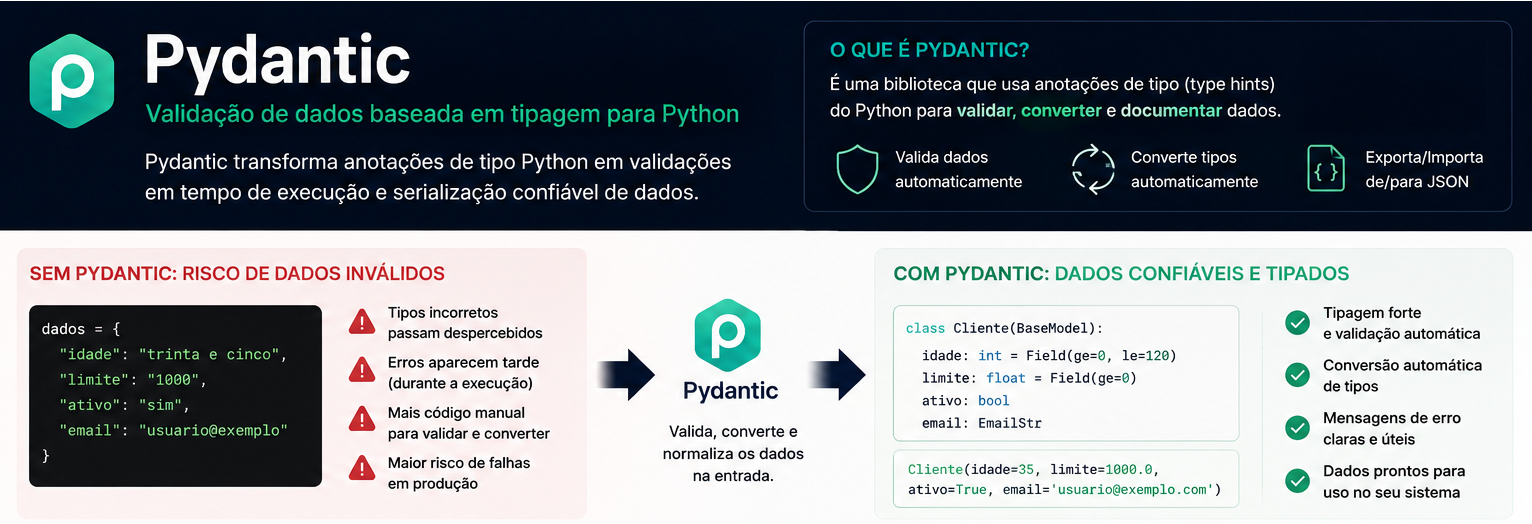

RuleCondition: estrutura que representa uma condição individual de uma regra de detecção, definindo qual característica será analisada, qual operador de comparação será usado e qual valor será utilizado como referência.

In [ ]:
# Vamos criar um modelo Pydantic para representar uma única condição de uma regra.
# TODO Crie uma Classe RuleCondition que herda BaseModel
class ...:

    #TODO defina "feature" como uma string fazendo feature: str
    # para armazenar o nome da característica utilizada na condição.
    ...

    #TODO defina "operator" usando Literal e permita somente os operadores
    # ">", ">=", "<", "<=" e "==" fazendo operator: Literal[">", ">=", "<", "<=", "=="].
    # Literal restringe o campo a um conjunto específico de valores permitidos.
    ...

    #TODO defina "value" como um número decimal fazendo value: float
    # para representar o valor utilizado na comparação com a feature.
    ...

RuleOutput: estrutura que representa a regra de detecção gerada pelo agente, definindo suas condições, como elas devem ser combinadas (AND ou OR) e a justificativa para a regra proposta.

In [ ]:
### Vamos criar um modelo Pydantic para representar a saída estruturada
### do agente RuleOutput. Herdar de BaseModel faz com que a classe passe
### a ser validada e possa ser convertida para formatos estruturados, como JSON.

# TODO Crie uma Classe RuleOutput que herda BaseModel
class ...:

    #TODO defina "conditions" como uma lista de objetos RuleCondition
    # fazendo conditions: List[RuleCondition].
    # Cada item da lista representa uma condição que fará parte da regra.
    # Use Field(min_length=1, max_length=4) para exigir no mínimo 1
    # e no máximo 4 condições.
    ...

    #TODO defina "logic" usando Literal e permita somente "AND" ou "OR".
    # Use "AND" como valor padrão fazendo logic: Literal["AND", "OR"] = "AND"
    ...

    #TODO defina "rationale" como uma string fazendo rationale: str
    # para armazenar a justificativa da regra gerada.
    ...

In [ ]:
#TODO gere o JSON Schema da classe RuleOutput usando model_json_schema()
RULE_SCHEMA = ...

In [ ]:
def build_baseline_examples(data: pd.DataFrame, n_each_class: int = 20) -> Dict[str, Any]:
    fraud = data[data["class"] == 1]
    legitimate = data[data["class"] == 0]

    fraud_n = min(n_each_class, len(fraud))
    legitimate_n = min(n_each_class, len(legitimate))

    fraud_sample = fraud.sample(n=fraud_n, random_state=SEED)
    legitimate_sample = legitimate.sample(n=legitimate_n, random_state=SEED)

    def serialize_rows(frame: pd.DataFrame) -> List[Dict[str, Any]]:
        return frame[FEATURES + ["class"]].to_dict(orient="records")

    return {
        "fraud_examples": serialize_rows(fraud_sample),
        "legitimate_examples": serialize_rows(legitimate_sample),
        "n_fraud_examples": fraud_n,
        "n_legitimate_examples": legitimate_n,
    }

In [ ]:
def propose_baseline_rule_with_llm(data: pd.DataFrame) -> Dict[str, Any]:
    examples = build_baseline_examples(data)

    system_prompt = """
Você é um analista de fraude encarregado de propor uma única regra antifraude.
Você não faz parte de um sistema multiagente.

Analise os exemplos fornecidos e proponha uma regra simples, explicável e estruturada.
A regra pode usar somente as features permitidas pelo schema.

RESTRIÇÕES:
- Esta é sua única oportunidade de propor a regra.
- Não haverá feedback, revisão ou nova tentativa.
- Não gere Python, SQL ou código executável.
- Não use informações do conjunto de teste.
- Prefira sinais que diferenciem as duas classes nos exemplos.
- A regra deve ser suficientemente geral para não depender de uma única transação.
- Responda em português do Brasil nos campos textuais.
"""


    # TODO Crie um user_prompt passando "Dada as amostrar de transações reais do conjunto de treino."
    # EXEMPLOS DE FRAUDE (class = 1): {json.dumps(examples['fraud_examples'], indent=2, ensure_ascii=False)}
    # EXEMPLOS LEGÍTIMOS (class = 0): {json.dumps(examples['legitimate_examples'], indent=2, ensure_ascii=False)}
    # Features permitidas: {FEATURES}
    # Finalize pedindo "Proponha uma única regra antifraude estruturada."

    user_prompt = f"""..."""


    #TODO envie o system_prompt, o user_prompt e o RULE_SCHEMA para a função
    # call_llm_json(), que solicita ao LLM uma resposta estruturada
    # de acordo com o JSON Schema definido anteriormente.
    raw = ...

    #TODO valide a resposta recebida utilizando o modelo Pydantic RuleOutput
    # chamando model_validate() e passando raw depois da validação, use
    # .model_dump() para converter o objeto Pydantic para um dicionário Python.
    rule = ...

    invalid_features = [
        c["feature"] for c in rule["conditions"]
        if c["feature"] not in FEATURES
    ]
    if invalid_features:
        raise ValueError(f"Features não permitidas na baseline: {invalid_features}")

    return rule

In [ ]:
baseline_examples = build_baseline_examples(train_df, n_each_class=20)
baseline_rule = propose_baseline_rule_with_llm(train_df)
baseline_train_metrics = evaluate_rule(train_df, baseline_rule)
baseline_test_metrics = evaluate_rule(test_df, baseline_rule)

print("🧠 BASELINE — LLM ÚNICO")
print(
    f"Exemplos fornecidos ao LLM: {baseline_examples['n_fraud_examples']} fraudes + "
    f"{baseline_examples['n_legitimate_examples']} legítimas"
)
print("Uma única chamada do LLM → uma única regra → avaliação determinística")
print_metrics(baseline_train_metrics, "BASELINE — TREINO")
print_metrics(baseline_test_metrics, "BASELINE — TESTE ISOLADO")

print("\nRegra baseline proposta pelo LLM:")
print(json.dumps(baseline_rule, indent=2, ensure_ascii=False))

#### Sistemas Multi-Agentes

Scout: agente responsável por analisar a transação e identificar padrões, sinais relevantes e hipóteses de fraude, fornecendo uma primeira avaliação do caso para orientar a geração da regra.

In [ ]:
### Vamos criar um modelo Pydantic para representar a saída estruturada
### do agente Scout. Herdar de BaseModel faz com que a classe passe
### a ser validada e possa ser convertida para formatos estruturados, como JSON.

# TODO Crie uma Classe ScoutOutput que herda BaseModel
class ...:

    #TODO defina "pattern" como uma string fazendo pattern: str
    # para armazenar o padrão identificado pelo agente.
    ...

    #TODO defina "relevant_signals" como uma lista de strings fazendo
    # relevant_signals: List[str] para armazenar os sinais ou características
    # relevantes encontrados pelo agente.
    ...

    #TODO defina "hypothesis" como uma string para armazenar a hipótese
    # fazendo hypothesis: str formulada a partir dos sinais identificados.
    ...

    #TODO  defina "confidence" como um número decimal entre 0 e 1
    # fazendo confidence: float = Field(default=0, ge=0, le=1) para representar
    # o nível de confiança do agente na hipótese.
    # ge significa "greater than or equal" e le significa "less than or equal".
    ...


In [ ]:
#TODO gere o JSON Schema da classe ScoutOutput usando model_json_schema()
SCOUT_SCHEMA = ...

In [ ]:
def build_case_context(case: pd.Series) -> Dict[str, Any]:
    all_stats = feature_stats
    values = {}
    for feature in all_stats["feature"]:
        values[feature] = float(case[feature])

    summary = []
    for _, row in all_stats.iterrows():
        f = row["feature"]
        summary.append({
            "feature": f,
            "case_value": float(case[f]),
            "mean_legitimate": float(row["mean_legitimate"]),
            "mean_fraud": float(row["mean_fraud"]),
            "standardized_difference": float(row["standardized_difference"]),
        })

    return {"purchase_value": float(case["purchase_value"]), "signals": summary}


In [ ]:
def run_scout(case: pd.Series) -> Dict[str, Any]:
    context = build_case_context(case)

    system_prompt = """
Você é o SCOUT de um sistema antifraude.
Todas as descrições e campos textuais devem ser escritos em português do Brasil.
Sua responsabilidade é investigar o caso e explicar sinais observáveis.
Use somente as evidências fornecidas.
Não proponha código e não proponha a regra ainda.
Responda estritamente no formato estruturado solicitado.
"""

    #TODO crie um user_prompt solicitando "Analise a transação abaixo."
    # dando o contexto do CONTEXTO DO CASO: {json.dumps(context, indent=2, ensure_ascii=False)}
    # e Pedindo o seguinte output:
    #Produza:
    #- pattern: descrição curta do padrão observado;
    #- relevant_signals: 2 a 5 sinais concretos;
    #- hypothesis: hipótese sobre por que o caso merece investigação;
    #- confidence: confiança entre 0 e 1.
    user_prompt = f"""..."""

    #TODO envie o system_prompt, o user_prompt e o SCOUT_SCHEMA para a função
    # call_llm_json(), que solicita ao LLM uma resposta estruturada
    # de acordo com o JSON Schema definido anteriormente.
    raw = ...

    #TODO valide a resposta recebida utilizando o modelo Pydantic ScoutOutput
    # chamando model_validate() e passando raw depois da validação, use
    # .model_dump() para converter o objeto Pydantic para um dicionário Python.
    result = ...

    print("🔎 [SCOUT]")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    return result

In [ ]:
def run_legislator(
    case: pd.Series,
    scout_output: Dict[str, Any],
    previous_rule: Optional[Dict[str, Any]] = None,
    previous_train_metrics: Optional[Dict[str, Any]] = None,
    best_rule: Optional[Dict[str, Any]] = None,
    best_train_metrics: Optional[Dict[str, Any]] = None,
    fraudador_feedback: Optional[Dict[str, Any]] = None,
    exploration_mode: str = "threshold",
    error_summary: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:
    available_features = FEATURES

    mode_instructions = {
        "threshold": "Explore limites alternativos nas features mais informativas. Altere thresholds de forma concreta e evite repetir exatamente a regra anterior.",
        "combination": "Explore combinação de sinais. Prefira 2 ou 3 condições usando AND ou OR para capturar relações que uma única condição não captura.",
        "coverage": "Priorize cobertura das fraudes perdidas apontadas pelo diagnóstico objetivo. Tente reduzir falsos negativos sem aumentar excessivamente os falsos positivos.",
        "boundary": "Refine as fronteiras de decisão. Procure thresholds próximos dos valores observados nos casos de erro e ajuste a regra para melhorar F1 no treino.",
    }

    system_prompt = f"""
Você é o LEGISLATOR de um sistema antifraude.
Todas as justificativas e demais campos textuais devem ser escritos em português do Brasil.
Transforme a investigação do SCOUT em uma regra simples, explicável e com boa capacidade de discriminação.

A regra deve conter no máximo 4 condições e usar somente:
{available_features}

Operadores permitidos:
>, >=, <, <=, ==

IMPORTANTE:
- Retorne somente a representação estruturada da regra.
- Não gere Python.
- Não gere SQL.
- Não use eval.
- Não invente features.
- Use o feedback objetivo do conjunto de treino para orientar a proposta.
- Não descarte uma regra anterior melhor sem uma razão clara.
- Tente produzir uma regra funcionalmente diferente da regra anterior quando ela não melhorar o desempenho.
- Evite repetir a mesma regra ou apenas reordenar suas condições.
- O objetivo é maximizar F1 no treino, equilibrando precision, recall e false positive rate.

ESTRATÉGIA DE EXPLORAÇÃO DESTA RODADA:
{mode_instructions.get(exploration_mode, mode_instructions["threshold"])}
"""

    #TODO Incremente o user_prompt solicitando a geração de uma nova regra candidata.
    # Passando o SCOUT: {json.dumps(scout_output, indent=2, ensure_ascii=False)}
    # CASO: {json.dumps(build_case_context(case), indent=2, ensure_ascii=False)}
    # REGRA ANTERIOR: {json.dumps(previous_rule, indent=2, ensure_ascii=False) if previous_rule else "Nenhuma."}
    # MÉTRICAS DA REGRA ANTERIOR NO TREINO:{json.dumps(previous_train_metrics, indent=2, ensure_ascii=False) if previous_train_metrics else "Nenhuma."}
    # MELHOR REGRA ENCONTRADA ATÉ AGORA: {json.dumps(best_rule, indent=2, ensure_ascii=False) if best_rule else "Nenhuma."}
    # MÉTRICAS DA MELHOR REGRA NO TREINO: {json.dumps(best_train_metrics, indent=2, ensure_ascii=False) if best_train_metrics else "Nenhuma."}
    # DIAGNÓSTICO OBJETIVO DE ERROS DA REGRA ANTERIOR: {json.dumps(error_summary, indent=2, ensure_ascii=False) if error_summary else "Nenhum."}
    # FEEDBACK DO FRAUDADOR: {json.dumps(fraudador_feedback, indent=2, ensure_ascii=False) if fraudador_feedback else "Nenhum."}
    user_prompt = f"""..."""


    user_prompt += """
Gere uma nova regra candidata para esta rodada. Ela deve ser uma alternativa real, não uma cópia da regra anterior. Não use o conjunto de teste para justificar a proposta.
"""


    #TODO envie o system_prompt, o user_prompt e o RULE_SCHEMA para a função
    # call_llm_json(), que solicita ao LLM uma resposta estruturada
    # de acordo com o JSON Schema definido anteriormente.
    raw = ...

    #TODO valide a resposta recebida utilizando o modelo Pydantic ScoutOutput
    # chamando model_validate() e passando raw depois da validação, use
    # .model_dump() para converter o objeto Pydantic para um dicionário Python.
    result = ...

    invalid_features = [
        c["feature"] for c in rule["conditions"]
        if c["feature"] not in available_features
    ]
    if invalid_features:
        raise ValueError(f"Features não permitidas: {invalid_features}")

    print("⚖️ [LEGISLATOR]")
    print(f"Estratégia: {exploration_mode}")
    print(json.dumps(rule, indent=2, ensure_ascii=False))
    return rule


In [ ]:
def apply_rule(data: pd.DataFrame, rule: Dict[str, Any]) -> pd.Series:
    masks = []

    for condition in rule["conditions"]:
        feature = condition["feature"]
        operator = condition["operator"]
        value = float(condition["value"])

        if feature not in data.columns:
            raise ValueError(f"Feature inexistente: {feature}")

        series = data[feature]

        if operator == ">":
            mask = series > value
        elif operator == ">=":
            mask = series >= value
        elif operator == "<":
            mask = series < value
        elif operator == "<=":
            mask = series <= value
        elif operator == "==":
            mask = np.isclose(series, value)
        else:
            raise ValueError(f"Operador não permitido: {operator}")

        masks.append(mask)

    if rule["logic"] == "AND":
        result = masks[0]
        for mask in masks[1:]:
            result = result & mask
    else:
        result = masks[0]
        for mask in masks[1:]:
            result = result | mask

    return result.astype(int)


def evaluate_rule(data: pd.DataFrame, rule: Dict[str, Any]) -> Dict[str, Any]:
    y_true = data["class"].astype(int)
    y_pred = apply_rule(data, rule)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) else 0.0,
        "captured_transactions": int(y_pred.sum()),
        "fraud_cases": int(y_true.sum()),
        "cases_evaluated": int(len(data)),
        "true_positive": int(tp),
        "false_positive": int(fp),
        "true_negative": int(tn),
        "false_negative": int(fn),
    }


def print_metrics(metrics: Dict[str, Any], title: str = "Avaliação"):
    print(f"📊 {title}")
    print(f"   Casos avaliados       : {metrics['cases_evaluated']:,}")
    print(f"   Transações capturadas : {metrics['captured_transactions']:,}")
    print(f"   Precision             : {metrics['precision']:.3f}")
    print(f"   Recall                : {metrics['recall']:.3f}")
    print(f"   F1                    : {metrics['f1']:.3f}")
    print(f"   False Positive Rate   : {metrics['false_positive_rate']:.3%}")

In [ ]:
fraud_cases = train_df[train_df["class"] == 1]
legitimate_cases = train_df[train_df["class"] == 0]

if fraud_cases.empty or legitimate_cases.empty:
    raise RuntimeError("O conjunto de treino precisa conter classes 0 e 1.")

CASE_INDEX = fraud_cases.index[0]
case = train_df.loc[CASE_INDEX].copy()

print(f"Caso usado pelo SCOUT nas iterações multiagente: índice {CASE_INDEX} do treino")
print(f"Classe real: {int(case['class'])} (1 = fraude)")
display(case[FEATURES].to_frame().T)


## 7. 🚨 FRAUDADOR

O FRAUDADOR assume uma postura adversarial e procura:
- valores no limite da regra;
- sinais que podem ser omitidos;
- combinações alternativas;
- casos próximos da fronteira;
- falsos negativos e falsos positivos.

O resultado do FRAUDADOR será estruturado e alimentará o routing do LangGraph.


FraudadorOutput: estrutura que representa a avaliação final de uma regra ou caso pelo agente Fraudador, registrando a decisão, os vetores de ataque identificados, possíveis contraexemplos e a justificativa da decisão.

In [ ]:
#Vamos criar um modelo Pydantic para representar a avaliação final do agente Fraudador.
# TODO Crie uma Classe FraudadorOutput que herda BaseModel
class ...:

    #TODO defina "status" usando Literal e permita somente
    # "REJECTED" ou "APPROVED" para representar a decisão final
    # fazendo status: Literal["REJECTED", "APPROVED"]
    ...

    #TODO defina "attack_vectors" como uma lista de strings fazendo
    # attack_vectors: List[str] para armazenar os vetores de ataque identificados.
    ...

    #TODO defina "counterexamples" como uma lista de strings fazendo
    # counterexamples: List[str] para armazenar possíveis contraexemplos
    # ou situações que podem contrariar a decisão tomada.
    ...

    #TODO defina "reason" como uma string fazendo reason: str
    # para armazenar a justificativa da decisão.
    ...

In [ ]:
#TODO gere o JSON Schema da classe FraudadorOutput usando model_json_schema()
FRAUDADOR_SCHEMA = ...

In [ ]:
def run_fraudador(
    rule: Dict[str, Any],
    train_sample: pd.DataFrame,
    scout_output: Dict[str, Any],
    train_metrics: Optional[Dict[str, Any]] = None,
) -> Dict[str, Any]:

    rule_mask = apply_rule(train_sample, rule)
    scored = train_sample.copy()
    scored["rule_decision"] = rule_mask

    distances = np.zeros(len(scored), dtype=float)

    for condition in rule["conditions"]:
        feature = condition["feature"]
        value = float(condition["value"])
        spread = float(scored[feature].std(ddof=0)) or 1.0
        distances += np.abs(scored[feature] - value) / spread

    scored["boundary_distance"] = distances

    boundary_cases = scored.sort_values("boundary_distance").head(12)
    compact_cases = boundary_cases[
        ["class"] + FEATURES + ["rule_decision"]
    ].to_dict(orient="records")

    missed_fraud_cases = int(
        ((boundary_cases["class"] == 1) &
         (boundary_cases["rule_decision"] == 0)).sum()
    )

    system_prompt = """
Você é o FRAUDADOR, um agente adversarial.
Todas as explicações, ataques, contraexemplos e justificativas devem ser escritos em português do Brasil.
Seu objetivo é tentar encontrar vulnerabilidades na regra antifraude usando somente dados do conjunto de treino fornecido.

Procure especificamente:
1. casos próximos da fronteira da regra;
2. casos reais de fraude que a regra deixa passar;
3. padrões de fraude não cobertos;
4. dependência excessiva de um único sinal;
5. queda objetiva de precision, recall ou F1 em relação à melhor tentativa anterior.

Se houver evidência suficiente de vulnerabilidade relevante, status = REJECTED.
Se a regra sobreviver à tentativa de ataque apresentada, status = APPROVED.

Não invente resultados do dataset.
Não use o conjunto de teste.
"""

    # TODO Crie um user_prompt passando:
    # REGRA: {json.dumps(rule, indent=2, ensure_ascii=False)}
    # MÉTRICAS DA REGRA NO TREINO: {json.dumps(train_metrics, indent=2, ensure_ascii=False) if train_metrics else "Nenhuma."}
    # ANÁLISE DO SCOUT: {json.dumps(scout_output, indent=2, ensure_ascii=False)}
    # CASOS REAIS PRÓXIMOS À FRONTEIRA NO TREINO: {json.dumps(compact_cases, indent=2, ensure_ascii=False, default=str)}
    user_prompt = f"""..."""


    #TODO envie o system_prompt, o user_prompt e o FRAUDADOR_SCHEMA para a função
    # call_llm_json(), que solicita ao LLM uma resposta estruturada
    # de acordo com o JSON Schema definido anteriormente. use temperature=0.3
    raw = ...

    #TODO valide a resposta recebida utilizando o modelo Pydantic FraudadorOutput
    # chamando model_validate() e passando raw depois da validação, use
    # .model_dump() para converter o objeto Pydantic para um dicionário Python.
    result = ...

    result["boundary_fraud_misses_in_sample"] = missed_fraud_cases

    if missed_fraud_cases > 0 and result["status"] == "APPROVED":
        result["status"] = "REJECTED"
        result["reason"] += (
            " A validação objetiva encontrou fraude não capturada "
            "entre os casos próximos à fronteira no treino."
        )

    print("🚨 [FRAUDADOR]")
    print(json.dumps(result, indent=2, ensure_ascii=False))
    return result


# 8. Estado compartilhado

Até aqui, os agentes eram funções independentes.

Agora vamos criar um **estado compartilhado**.

Cada agente:
- lê informações do estado;
- executa sua responsabilidade;
- escreve seu resultado de volta no estado.

O estado será nosso "quadro branco" compartilhado:

```text
case
scout_analysis
rule
fraudador_feedback
audit
attempt
route
```

In [ ]:
class AgentState(TypedDict, total=False):
    case: Dict[str, Any]
    scout_analysis: Dict[str, Any]
    rule: Dict[str, Any]
    train_metrics: Dict[str, Any]
    error_summary: Dict[str, Any]
    fraudador_feedback: Dict[str, Any]
    audit: Dict[str, Any]
    best_rule: Dict[str, Any]
    best_train_metrics: Dict[str, Any]
    best_score: float
    attempt: int
    max_attempts: int
    exploration_mode: str
    route: str


def state_preview(state: AgentState) -> str:
    return json.dumps(
        {
            "attempt": state.get("attempt"),
            "route": state.get("route"),
            "exploration_mode": state.get("exploration_mode"),
            "best_f1_treino": state.get("best_train_metrics", {}).get("f1"),
            "has_scout": "scout_analysis" in state,
            "has_rule": "rule" in state,
            "has_error_summary": "error_summary" in state,
            "has_fraudador_feedback": "fraudador_feedback" in state,
            "has_audit": "audit" in state,
        },
        indent=2,
        ensure_ascii=False,
    )


# 9. Construindo os nós do LangGraph

Agora vamos transformar os agentes em nós do workflow.

A ideia é perceber que **LangGraph não é o agente**.

O LangGraph orquestra:
- estado;
- sequência;
- caminhos;
- loops.

Os agentes continuam tendo responsabilidades específicas.

In [ ]:
EXPLORATION_MODES = ["threshold", "combination", "coverage", "boundary"]


def build_error_summary(df: pd.DataFrame, rule: Dict[str, Any], max_examples: int = 5) -> Dict[str, Any]:
    decisions = apply_rule(df, rule).astype(int)
    actual = df["class"].astype(int)

    false_negatives = df[(actual == 1) & (decisions == 0)]
    false_positives = df[(actual == 0) & (decisions == 1)]

    def summarize_cases(cases: pd.DataFrame) -> Dict[str, Any]:
        if cases.empty:
            return {"count": 0, "examples": []}
        examples = cases[FEATURES + ["class"]].head(max_examples).to_dict(orient="records")
        return {
            "count": int(len(cases)),
            "mean_features": {f: float(cases[f].mean()) for f in FEATURES},
            "examples": examples,
        }

    return {
        "false_negatives": summarize_cases(false_negatives),
        "false_positives": summarize_cases(false_positives),
    }


In [ ]:
def scout_node(state: AgentState) -> Dict[str, Any]:

    # TODO Chame o agente Scout usando run_scout e pasando os dados do caso
    # atual usando pd.Series(state["case"])
    analysis = ...

    return {
        "scout_analysis": analysis,
        "attempt": state.get("attempt", 0),
        "exploration_mode": state.get("exploration_mode", EXPLORATION_MODES[0]),
    }

In [ ]:
def legislator_node(state: AgentState) -> Dict[str, Any]:
    attempt_number = state.get("attempt", 0)
    previous_rule = state.get("rule")
    previous_metrics = state.get("train_metrics")
    error_summary = state.get("error_summary")

    # TODO Chame o agente Legislator usando run_legislator e passando:
    # - os dados do caso atual usando case=pd.Series(state["case"]);
    # - a análise produzida pelo agente Scout usando scout_output=state["scout_analysis"]
    # - a regra anterior usando previous_rule=previous_rule e suas métricas de treino;
    # - a melhor regra encontrada até o momento usando  best_rule=state.get("best_rule");
    # - As métricas anteriores de treino usando previous_train_metrics=previous_metrics;
    # - As melhores métricas de treino usando best_train_metrics=state.get("best_train_metrics")
    # - o feedback produzido pelo agente Fraudador usando fraudador_feedback=state.get("fraudador_feedback");
    # - o modo de exploração atual, usando exploration_mode=state.get("exploration_mode", EXPLORATION_MODES[attempt_number % len(EXPLORATION_MODES)]);
    # - o diagnóstico objetivo dos erros da regra anterior usando error_summary=error_summary.

    rule = ...

    candidate_metrics = evaluate_rule(train_df, rule)
    candidate_error_summary = build_error_summary(train_df, rule)
    candidate_f1 = candidate_metrics["f1"]
    best_f1 = state.get("best_score", -1.0)

    # Evita que o LLM gere repetidamente a mesma regra sem ganho.
    same_as_previous = previous_rule == rule if previous_rule else False

    if candidate_f1 >= best_f1 and not same_as_previous:
        best_rule = rule
        best_train_metrics = candidate_metrics
        best_score = candidate_f1
        print(f"🏆 [CAMPEÃO] Nova melhor regra no treino — F1={candidate_f1:.3f}")
    else:
        best_rule = state.get("best_rule", rule)
        best_train_metrics = state.get("best_train_metrics", candidate_metrics)
        best_score = best_f1
        reason = "regra repetida" if same_as_previous else "F1 inferior ao campeão"
        print(
            f"↩️ [CAMPEÃO] Candidata descartada — {reason}; "
            f"F1={candidate_f1:.3f}; melhor={best_f1:.3f}"
        )

    return {
        "rule": rule,
        "train_metrics": candidate_metrics,
        "error_summary": candidate_error_summary,
        "best_rule": best_rule,
        "best_train_metrics": best_train_metrics,
        "best_score": best_score,
        "attempt": attempt_number + 1,
        "exploration_mode": EXPLORATION_MODES[(attempt_number + 1) % len(EXPLORATION_MODES)],
    }

In [ ]:
def fraudador_node(state: AgentState) -> Dict[str, Any]:
    train_pool = train_df.sample(
        n=min(2500, len(train_df)),
        random_state=SEED + state.get("attempt", 0),
    )

    # TODO Chame o Fraudador usando run_fraudador e passando
    # a regra gerada pelo legislador rule=state["rule"]
    # a amostra de dados de treino train_sample=train_pool
    # a análise produzida pelo Scout scout_output=state["scout_analysis"]
    # as métricas de treino quando existir passando train_metrics=state.get("train_metrics")
    feedback = ...
    return {"fraudador_feedback": feedback}

In [ ]:
def auditor_node(state: AgentState) -> Dict[str, Any]:
    print("✅ [AUDITOR]")
    champion_rule = state.get("best_rule", state["rule"])
    metrics = evaluate_rule(test_df, champion_rule)
    print_metrics(metrics, "AUDITOR — TESTE REAL E ISOLADO")
    return {
        "audit": metrics,
        "rule": champion_rule,
        "route": "AUDITED",
    }


print("Nós dos agentes definidos.")


## Routing condicional

Agora implementamos a parte que diferencia um pipeline linear de um workflow agentivo.

O resultado do FRAUDADOR decide o próximo passo:

```text
FRAUDADOR
   │
   ├── REJECTED ──→ LEGISLATOR
   │
   └── APPROVED ──→ AUDITOR
```

Também colocamos um limite de tentativas.

Loops precisam de uma condição de parada explícita.

In [ ]:
def route_after_fraudador(state: AgentState) -> str:
    feedback = state["fraudador_feedback"]
    attempt = state.get("attempt", 0)
    max_attempts = state.get("max_attempts", 5)
    candidate_f1 = state.get("train_metrics", {}).get("f1", 0.0)
    best_f1 = state.get("best_train_metrics", {}).get("f1", candidate_f1)

    needs_revision = (
        feedback["status"] == "REJECTED"
        or candidate_f1 < best_f1
    )

    # TODO Crie uma condição que se precisar de revisão (needs_revision)
    # e ainda não estiver ultrapassado o limite de tentativas (attempt < max_attempts)
    # chame o legislador
    if ...:
        print("🔄 Routing: nova estratégia de exploração → LEGISLATOR")
        return "legislator"

    # TODO Crie uma condição que se precisar de revisão (needs_revision)
    # e já estiver ultrapassado o limite de tentativas (attempt >= max_attempts)
    # chame o auditor
    if ...:
        print("⛔ Limite de tentativas atingido → AUDITOR com a melhor regra encontrada")
        return "auditor"

    print("➡️ Routing: regra sobreviveu aos testes → AUDITOR com a melhor regra encontrada")
    return "auditor"

In [ ]:
# TODO Crie um StateGraph passando AgentState como estado compartilhado.
graph_builder = ...

# TODO adicione o nó "scout" usando graph_builder.add_node("scout", scout_node).
...

# TODO adicione o nó "legislator" usando graph_builder.add_node("legislator", legislator_node).
...

# TODO adicione o nó "fraudador" usando graph_builder.add_node("fraudador", fraudador_node).
...

# TODO adicione o nó "auditor" usando graph_builder.add_node("auditor", auditor_node).
...

# TODO conecte START ao nó "scout" usando graph_builder.add_edge(START, "scout").
...

# TODO conecte "scout" a "legislator" usando graph_builder.add_edge("scout", "legislator").
...

# TODO conecte "legislator" a "fraudador" usando graph_builder.add_edge("legislator", "fraudador").
...

# TODO adicione arestas condicionais após "fraudador" usando
# graph_builder.add_conditional_edges("fraudador", route_after_fraudador,
# { "legislator": "legislator", "auditor": "auditor", },).
...

# TODO conecte "auditor" ao END usando graph_builder.add_edge("auditor", END).
...

# TODO compile o grafo usando graph_builder.compile()
# e armazene o resultado em agentic_graph.
agentic_graph = ...

## Visualizando o workflow

O desenho abaixo mostra a arquitetura lógica implementada.

O ponto pedagógico é observar o **loop**: a mesma regra pode voltar ao LEGISLATOR depois de uma crítica do FRAUDADOR.

In [ ]:
from graphviz import Digraph

dot = Digraph("AgenticFraudRuleFactory", format="png")
dot.attr(rankdir="TB", bgcolor="transparent")
dot.node("start", "Fraud Case", shape="oval")
dot.node("scout", "🔎 SCOUT", shape="box")
dot.node("legislator", "⚖️ LEGISLATOR", shape="box")
dot.node("fraudador", "🚨 FRAUDADOR", shape="box")
dot.node("auditor", "✅ AUDITOR", shape="box")
dot.edge("start", "scout")
dot.edge("scout", "legislator")
dot.edge("legislator", "fraudador")
dot.edge("fraudador", "legislator", label=" REJECTED")
dot.edge("fraudador", "auditor", label=" APPROVED")

display(Image(dot.pipe(format="png")))

# 10. Executando o sistema multiagente

In [ ]:
initial_state: AgentState = {
    "case": case.to_dict(),
    "attempt": 0,
    "max_attempts": 5,
    "best_rule": baseline_rule,
    "best_train_metrics": baseline_train_metrics,
    "best_score": baseline_train_metrics["f1"],
    "exploration_mode": "threshold",
}

print(
    f"🏆 Regra inicial do ciclo: baseline com F1 de treino = "
    f"{baseline_train_metrics['f1']:.3f}"
)
print("🔁 Estratégias de exploração: threshold → combination → coverage → boundary")

final_state = agentic_graph.invoke(initial_state)

print("\n==============================")
print("ESTADO FINAL DO WORKFLOW")
print("==============================")
print(state_preview(final_state))


# 11. Inspecionando a regra final

O sistema terminou com uma regra estruturada.

A regra é um objeto Python comum e pode ser:
- armazenada;
- versionada;
- auditada;
- testada;
- executada sem LLM.

Esse desacoplamento é importante para sistemas de produção:
o LLM propõe; uma camada determinística aplica.

In [ ]:
final_rule = final_state["rule"]

print("⚖️ Regra campeã final:")
print(json.dumps(final_rule, indent=2, ensure_ascii=False))

print("\nAplicação da regra em algumas transações do teste:")
preview = test_df.sample(8, random_state=SEED).copy()
preview["rule_decision"] = apply_rule(preview, final_rule)

display(preview[FEATURES + ["class", "rule_decision"]])


# 12. Auditoria objetiva

Agora o AUDITOR mede a regra em **todo o conjunto de teste**.

Não estamos perguntando ao LLM se a regra parece boa.

Estamos calculando:
- precision;
- recall;
- F1;
- false positive rate;
- número de transações capturadas;
- matriz de confusão.

O resultado abaixo é calculado em tempo de execução a partir dos dados reais carregados no notebook.

In [ ]:
final_metrics = final_state["audit"]
print_metrics(final_metrics, "RESULTADO FINAL — SISTEMA MULTIAGENTE")

cm = np.array([
    [final_metrics["true_negative"], final_metrics["false_positive"]],
    [final_metrics["false_negative"], final_metrics["true_positive"]],
])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    square=True,
    xticklabels=["Predito legítimo", "Predito fraude"],
    yticklabels=["Real legítimo", "Real fraude"],
)
plt.xlabel("Predição da regra")
plt.ylabel("Classe real")
plt.title("Matriz de Confusão — Regra Campeã Final")
plt.tight_layout()
plt.show()


# 13. ANTES vs. DEPOIS

Agora comparamos os dois processos no **mesmo conjunto de teste isolado**.

### ANTES — LLM único

Uma única chamada de LLM recebe exemplos reais do treino e propõe uma regra.

### DEPOIS — sistema multiagente

SCOUT → LEGISLATOR → FRAUDADOR → diagnóstico de erros → nova estratégia → seleção da melhor regra → AUDITOR

A principal mudança não é apenas usar mais chamadas de LLM. O sistema ganhou:

- responsabilidades especializadas;
- estado compartilhado;
- crítica adversarial;
- routing condicional;
- loop de revisão;
- seleção da melhor regra encontrada no treino;
- avaliação final independente no teste.


In [ ]:
comparison = pd.DataFrame([
    {
        "Arquitetura": "Baseline",
        "Precision": baseline_test_metrics["precision"],
        "Recall": baseline_test_metrics["recall"],
        "F1": baseline_test_metrics["f1"],
        "False Positive Rate": baseline_test_metrics["false_positive_rate"],
        "Casos Capturados": baseline_test_metrics["captured_transactions"],
    },
    {
        "Arquitetura": "Multiagente",
        "Precision": final_metrics["precision"],
        "Recall": final_metrics["recall"],
        "F1": final_metrics["f1"],
        "False Positive Rate": final_metrics["false_positive_rate"],
        "Casos Capturados": final_metrics["captured_transactions"],
    }
])

display(
    comparison.style.format({
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "False Positive Rate": "{:.3%}",
        "Casos Capturados": "{:,.0f}",
    })
)


In [ ]:
comparison.set_index("Arquitetura")[["Precision", "Recall", "F1"]].plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 1),
)

plt.title("ANTES vs. DEPOIS")
plt.ylabel("Métrica")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.tight_layout()
plt.show()

# 🎯 Conclusão
Nesta aula prática, vimos como:
- transformar uma aplicação baseada em um único LLM em um sistema com agentes especializados;
- usar **estado compartilhado** para transportar informações entre SCOUT, LEGISLATOR, FRAUDADOR e AUDITOR;
- construir um workflow com **LangGraph**, routing condicional e loop com condição de parada;
- separar a proposta de uma regra feita pelo LLM da execução determinística da regra em Python;
- usar o conjunto de treino para crítica, revisão e seleção da melhor regra encontrada;
- manter o conjunto de teste isolado para uma auditoria final e objetiva.
